# Lab 3: Preprocessing and train-test split

Fixed the filename, supplied column names for the headerless Iris CSV, and excluded numeric Species labels from input features to avoid target leakage. Preserves the provided duplicate removal, missing-value handling and stratified split. Scaling demonstrations are descriptive; no model is trained on them.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split





df = pd.read_csv("IRIS.csv", header=None, names=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"])

print("First 5 observations:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)






print("\n--- Particular Column ---")


print(df["SepalLengthCm"].head())






print("\n--- Summary Statistics ---")

print(df.describe())






print("\n--- Mean ---")

numeric_columns = df.select_dtypes(include=np.number).columns.drop("Species")

mean_values = df[numeric_columns].mean()
print(mean_values)

print("\n--- Standard Deviation ---")

std_values = df[numeric_columns].std()
print(std_values)







print("\n--- Duplicate Values ---")

print("Duplicates before removal:",
      df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Duplicates after removal:",
      df.duplicated().sum())



print("\n--- Missing Values ---")

print(df.isnull().sum())



for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())


if "Species" in df.columns:
    df["Species"] = df["Species"].fillna(
        df["Species"].mode()[0]
    )

print("\nMissing values after preprocessing:")
print(df.isnull().sum())



print("\n--- Standardization ---")

X = df[numeric_columns]

standard_scaler = StandardScaler()

X_standardized = standard_scaler.fit_transform(X)

X_standardized = pd.DataFrame(
    X_standardized,
    columns=numeric_columns
)

print(X_standardized.head())



print("\n--- Normalization ---")

min_max_scaler = MinMaxScaler()

X_normalized = min_max_scaler.fit_transform(X)

X_normalized = pd.DataFrame(
    X_normalized,
    columns=numeric_columns
)

print(X_normalized.head())



print("\n--- Data Balancing ---")

print(df["Species"].value_counts())

print("\nClass proportions:")
print(df["Species"].value_counts(normalize=True))






print("\n--- Train Test Split ---")

X = df[numeric_columns]
Y = df["Species"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

print("X_train:")
print(X_train.head())

print("\nX_test:")
print(X_test.head())

print("\nY_train:")
print(Y_train.head())

print("\nY_test:")
print(Y_test.head())

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)


First 5 observations:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        1
1            4.9           3.0            1.4           0.2        1
2            4.7           3.2            1.3           0.2        1
3            4.6           3.1            1.5           0.2        1
4            5.0           3.6            1.4           0.2        1

Shape:
(150, 5)

Columns:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

--- Particular Column ---
0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: SepalLengthCm, dtype: float64

--- Summary Statistics ---
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm     Species
count     150.000000    150.000000     150.000000    150.000000  150.000000
mean        5.843333      3.057333       3.758000      1.199333    2.000000
std         0.828066      0.435866       1.765298      0.76

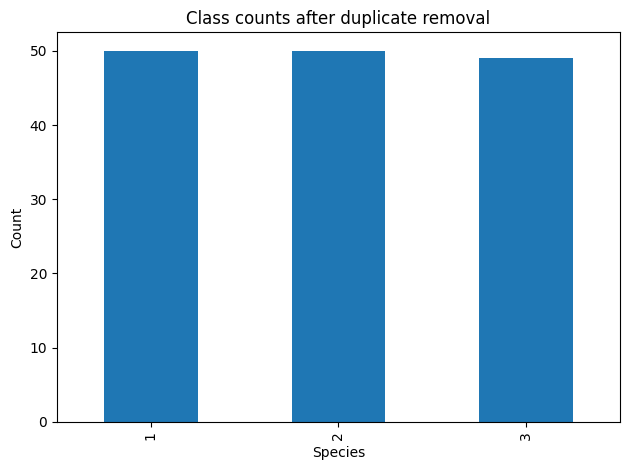

Class balancing check: counts shown above; no synthetic resampling is applied.


In [3]:
df['Species'].value_counts().sort_index().plot.bar(title='Class counts after duplicate removal');plt.xlabel('Species');plt.ylabel('Count');plt.tight_layout();plt.show()
print('Class balancing check: counts shown above; no synthetic resampling is applied.')